# 03 — Preprocessing and Augmentation
## Skin Cancer Classification – HAM10000 Dataset

### Objective

This notebook prepares the HAM10000 dataset for model training.

The goals are to:
- create clean train / validation / test splits,
- avoid data leakage using lesion-level splitting,
- encode labels,
- define image preprocessing transformations,
- define data augmentation strategies,
- prepare PyTorch datasets and dataloaders.

## 1. Imports

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

from PIL import Image

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt

## 2. Load Metadata

In [2]:
PROJECT_ROOT = Path("..")
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

METADATA_PATH = RAW_DIR / "HAM10000_metadata.csv"

metadata = pd.read_csv(METADATA_PATH)
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## 3. Add image paths

In [3]:
IMAGE_DIR_1 = RAW_DIR / "HAM10000_images_part_1"
IMAGE_DIR_2 = RAW_DIR / "HAM10000_images_part_2"

image_paths = {}

for image_dir in [IMAGE_DIR_1, IMAGE_DIR_2]:
    for image_path in image_dir.glob("*.jpg"):
        image_paths[image_path.stem] = image_path

metadata["image_path"] = metadata["image_id"].map(image_paths)

metadata["image_path"].isnull().sum()

np.int64(0)

## 4. Encode Labels

In [4]:
label_encoder = LabelEncoder()

metadata["label"] = label_encoder.fit_transform(metadata["dx"])

label_mapping = dict(
    zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
)

label_mapping

{'akiec': np.int64(0),
 'bcc': np.int64(1),
 'bkl': np.int64(2),
 'df': np.int64(3),
 'mel': np.int64(4),
 'nv': np.int64(5),
 'vasc': np.int64(6)}

## 5. Lesion-level train / validation / test split

In [5]:
groups = metadata["lesion_id"]

### Train + temporary split

In [6]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    gss.split(metadata, metadata["label"], groups=groups)
)

train_df = metadata.iloc[train_idx].reset_index(drop=True)
temp_df = metadata.iloc[temp_idx].reset_index(drop=True)

### Validation + test split

In [7]:
gss_val_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss_val_test.split(
        temp_df,
        temp_df["label"],
        groups=temp_df["lesion_id"]
    )
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

## 6. Verify split sizes

In [8]:
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 7002
Validation size: 1519
Test size: 1494


In [9]:
print("Train percentage:", round(len(train_df) / len(metadata) * 100, 2))
print("Validation percentage:", round(len(val_df) / len(metadata) * 100, 2))
print("Test percentage:", round(len(test_df) / len(metadata) * 100, 2))

Train percentage: 69.92
Validation percentage: 15.17
Test percentage: 14.92


## 7. Check leakage between splits

In [10]:
train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

print("Train / Val overlap:", len(train_lesions.intersection(val_lesions)))
print("Train / Test overlap:", len(train_lesions.intersection(test_lesions)))
print("Val / Test overlap:", len(val_lesions.intersection(test_lesions)))

Train / Val overlap: 0
Train / Test overlap: 0
Val / Test overlap: 0


## 8. Check class distribution after split

In [11]:
def class_distribution(df, name):
    distribution = (
        df["dx"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .reset_index()
    )
    
    distribution.columns = ["class", f"{name}_percentage"]
    return distribution

In [12]:
train_dist = class_distribution(train_df, "train")
val_dist = class_distribution(val_df, "val")
test_dist = class_distribution(test_df, "test")

split_distribution = (
    train_dist
    .merge(val_dist, on="class", how="outer")
    .merge(test_dist, on="class", how="outer")
)

split_distribution

,class,train_percentage,val_percentage,test_percentage
0,akiec,2.96,3.75,4.22
1,bcc,5.44,4.28,4.55
2,bkl,10.58,13.56,10.17
3,df,1.27,1.25,0.47
4,mel,11.00,10.27,12.52
5,nv,67.38,65.24,66.67
6,vasc,1.37,1.65,1.41


## 9. Save processed metadata splits

In [13]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(PROCESSED_DIR / "train_metadata.csv", index=False)
val_df.to_csv(PROCESSED_DIR / "val_metadata.csv", index=False)
test_df.to_csv(PROCESSED_DIR / "test_metadata.csv", index=False)

## 10. Define image transformations

### Training transformations

In [14]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Validation / test transformations

In [15]:
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 11. Custom PyTorch Dataset

In [16]:
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        image_path = row["image_path"]
        label = row["label"]
        
        image = Image.open(image_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

## 12. Create datasets

In [17]:
train_dataset = HAM10000Dataset(
    train_df,
    transform=train_transforms
)

val_dataset = HAM10000Dataset(
    val_df,
    transform=eval_transforms
)

test_dataset = HAM10000Dataset(
    test_df,
    transform=eval_transforms
)

## 13. Create dataloaders

In [18]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

## 14. Verify one batch

In [19]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


## 15. Visualize augmented images

In [20]:
def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    tensor = tensor * std + mean
    tensor = torch.clamp(tensor, 0, 1)
    
    return tensor

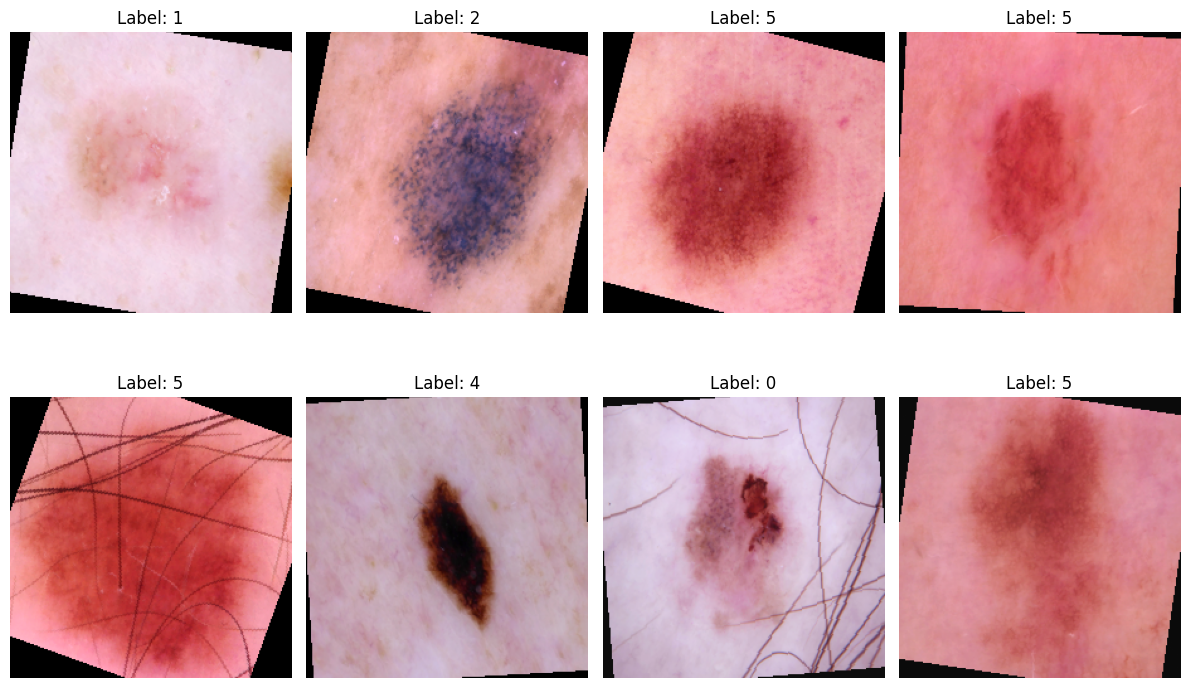

In [21]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(8):
    image = denormalize_image(images[i]).permute(1, 2, 0)
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 16. Preprocessing Summary

- Metadata was split into train, validation, and test sets.
- Splitting was performed at lesion level to reduce data leakage risk.
- No lesion identifier overlap was found between the splits.
- Labels were encoded numerically for model training.
- Training images use augmentation to improve generalization.
- Validation and test images use deterministic preprocessing only.
- PyTorch datasets and dataloaders were successfully created.